# Text Classification with Naive Bayes, Logistic Regression, SVM


**Overview:** This notebook aims to give you a brief overview of performing text classification using Naive Bayes, Logistic Regression and Support Vector Machines. We will be using a dataset called "Economic news article tone and relevance" from [Figure-Eight](https://github.com/practical-nlp/practical-nlp/blob/master/Ch4/Data/Full-Economic-News-DFE-839861.csv) which consists of approximately 8000 news articles, which were tagged as relevant or not relevant to the US Economy. Our goal in this notebook is to explore the process of training and testing text classifiers for this problem, using this data set and two text classification algorithms: Multinomial Naive Bayes and Logistic Regression, implemented in sklearn. 

<br><br>
Let's import few necessary packages before we start our work

In [31]:
!pip install --upgrade numpy matplotlib scikit-learn pandas


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [32]:
import pandas as pd
import numpy as np
import string
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


### Section 1: Load and explore the dataset

In [33]:
# 2. Load and Prepare Data
# Assuming you have the CSV file 'Dataset-text-classification.csv'
df = pd.read_csv("Dataset-text-classification.csv", encoding='ISO-8859-1')




In [34]:
display(df.shape) # Number of rows (instances) and columns in the dataset
df["relevance"].value_counts()/df.shape[0] # Class distribution in the dataset

(8000, 15)

relevance
no          0.821375
yes         0.177500
not sure    0.001125
Name: count, dtype: float64

There is an imbalance in the data with **not relevant** being 82% in the dataset. That is, most of the articles are not relevant to US Economy, which makes sense in a real-world scenario, as news articles discuss various topics. We should keep this class imbalance mind when interpreting the classifier performance later. Let us first convert the class labels into binary outcome variables for convenience. 1 for Yes (relevant), and 0 for No (not relevant), and ignore "Not sure". 

In [35]:
# Keep only relevant/not relevant, drop "not sure"
df = df[df.relevance != "not sure"].copy()
print(df.shape)
df['relevance'] = df.relevance.map({'yes': 1, 'no': 0}) # relevant is 1, not-relevant is 0.

X = df['text']
y = df['relevance']



(7991, 15)


### Section 2: Text Pre-processing

Typical steps involve tokenization, lower casing, removing, stop words, punctuation markers etc, and vectorization. Other processes such as stemming/lemmatization can also be performed. Here, we are performing the following steps: removing br tags, punctuation, numbers, and stopwords. While we are using sklearn's list of stopwords, there are several other stop word lists (e.g., from NLTK) or sometimes, custom stopword lists are needed depending on the task. 

In [36]:

# Preprocessing Function
def clean(doc):
    # Ensure doc is a string
    doc = str(doc)
    # Remove HTML tags
    doc = re.sub(r'<[^>]+>', '', doc)
    # Remove punctuation
    doc = "".join([char for char in doc if char not in string.punctuation])
    # Lowercase and remove stop words
    tokens = doc.lower().split()
    return " ".join([token for token in tokens if token not in ENGLISH_STOP_WORDS])




### Section 3: Modeling

Now we are ready for the modelling. We are going to use algorithms from sklearn package. We will go through the following steps:

1 Split the data into training and test sets (75% train, 25% test)    
2 Extract features from the training data using CountVectorizer, which is a bag of words feature  implementation. We will use the pre-processing function above in conjunction with Count Vectorizer  
3 Transform the test data into the same feature vector as the training data.  
4 Train the classifier  
5 Evaluate the classifier  

Accuracy: 0.8043


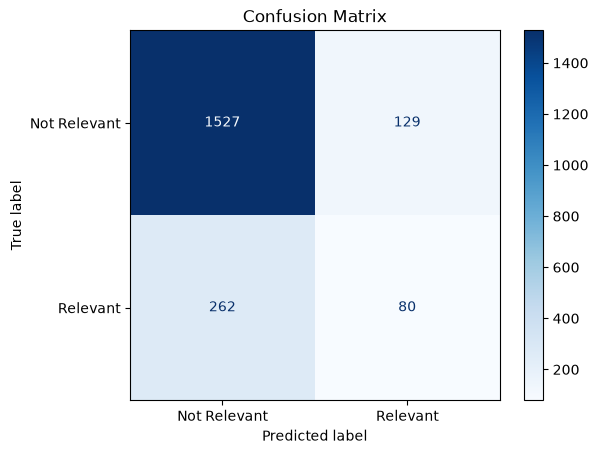

In [37]:

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

# Feature Extraction
# Using the clean function inside CountVectorizer
vect = CountVectorizer(preprocessor=clean)
X_train_dtm = vect.fit_transform(X_train)
X_test_dtm = vect.transform(X_test)

# Modeling (e.g., Multinomial Naive Bayes)
nb = MultinomialNB()
nb.fit(X_train_dtm, y_train)
y_pred = nb.predict(X_test_dtm)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Visualization
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Relevant', 'Relevant'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

At this point, we can notice that the classifier is doing poorly with identifying relevant articles, while it is doing well with non-relevant ones. Our large feature vector could be creating a lot of noise in the form of very rarely occurring features that are not useful for learning. Let us change the count vectorizer to take a certain number of features as maximum. 

Accuracy: 0.6927


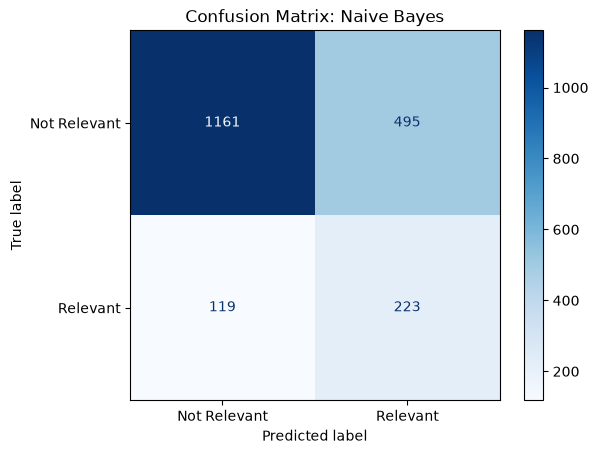

In [38]:
# Feature Extraction
# Using the clean function inside CountVectorizer
vect = CountVectorizer(preprocessor=clean, max_features=5000)
X_train_dtm = vect.fit_transform(X_train)
X_test_dtm = vect.transform(X_test)

# Modeling (e.g., Multinomial Naive Bayes)
nb = MultinomialNB()
nb.fit(X_train_dtm, y_train)
y_pred = nb.predict(X_test_dtm)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Visualization
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Relevant', 'Relevant'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Naive Bayes")
plt.show()

Clearly, the performance on relevance classification got better even though the overall accuracy fell by 10%. Let us try another classification algorithm and see if the performance changes. For this experiment, we have considered logistic regression, with class_weight attribute as "balanced", to address the problem of class imbalance in this dataset. 

Accuracy: 0.7327


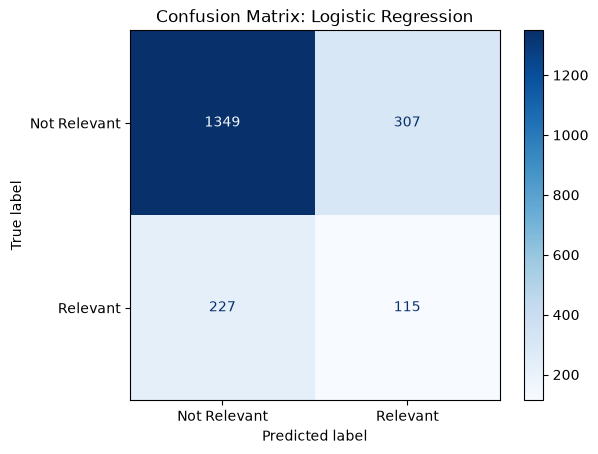

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Instantiate the model with balanced class weights
# This helps the model penalize mistakes on the minority class more heavily
logreg = LogisticRegression(class_weight="balanced", solver='liblinear') 

# Fit the model on the training data
logreg.fit(X_train_dtm, y_train)

# Predict on the test data
y_pred_logreg = logreg.predict(X_test_dtm)


print(f"Accuracy: {accuracy_score(y_test, y_pred_logreg):.4f}")

# Visualization
cm = confusion_matrix(y_test, y_pred_logreg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Relevant', 'Relevant'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Logistic Regression")
plt.show()









Accuracy: 0.6797


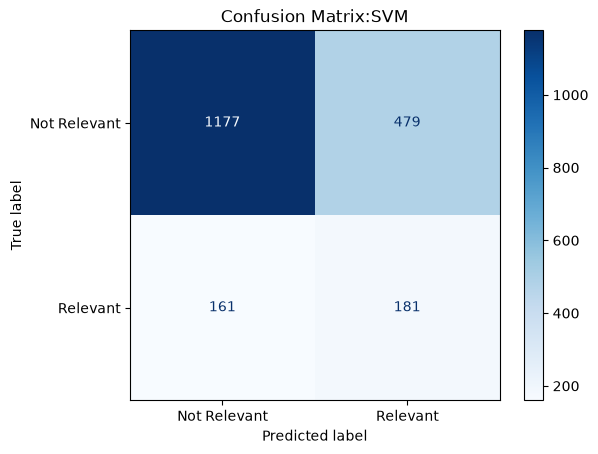

In [40]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

vect = CountVectorizer(preprocessor=clean, max_features=1000) #Step-1
X_train_dtm = vect.fit_transform(X_train)#combined step 2 and 3
X_test_dtm = vect.transform(X_test)
classifier = LinearSVC(class_weight='balanced') #notice the “balanced” option
classifier.fit(X_train_dtm, y_train) #fit the model with training data
y_pred_class = classifier.predict(X_test_dtm)



print(f"Accuracy: {accuracy_score(y_test, y_pred_class):.4f}")

# Visualization
cm = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Relevant', 'Relevant'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix:SVM")
plt.show()


So, how do we choose whats the best? If we look at overall accuracy alone, we should be choosing the very first classifier in this notebook. However, that is also doing poorly with identifying "relevant" articles. If we choose purely based on how good it is doing with "relevant" category, we should choose the second one we built. If we choose purely based on how good it is doing with "irrelevant" category, surely, nothing beats not building any classifier and just calling everything irrelevant! So, what to choose as the best among these depends on what we are looking for in our usecase! 